# Recommender Systems I
# Simple Recommender Systems

### Import Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings 
warnings.filterwarnings('ignore') 

Recipe Data:

In [2]:
recipe_data = pd.read_csv('recipe_data/RAW_recipes.csv',header=0,sep=",")
recipe_data.head(1)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7


User Data:

In [3]:
user_data = pd.read_csv('recipe_data/PP_users.csv',header=0,sep=",")
user_data.head(1)

,u,techniques,items,n_items,ratings,n_ratings
0,0,"[8, 0, 0, 5, 6, 0, 0, 1, 0, 9, 1, 0, 0, 0, 1, ...","[1118, 27680, 32541, 137353, 16428, 28815, 658...",31,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, ...",31


### Preprocessing

Unpacking the data:

In [4]:
df = pd.DataFrame(columns = ['User','Item','Rating'])

for i in tqdm(range(len(user_data))):
    
    user_items = str(user_data['items'][i])
    user_items = [int(x) for x in user_items.replace('[','') \
                                            .replace(']','') \
                                            .replace(',','').split()]
    
    user_ratings = str(user_data['ratings'][i])
    user_ratings = [float(x) for x in user_ratings.replace('[','') \
                                                  .replace(']','') \
                                                  .replace(',','').split()]
    
    user = user_data['u'][i]
    user = list(np.repeat(user,len(user_items)))
    
    sub_df = pd.DataFrame(columns = ['User','Item','Rating'])
    sub_df['User'] = user
    sub_df['Item'] = user_items
    sub_df['Rating'] = user_ratings
    
    df = pd.concat([df, sub_df])

Saving the result to file:

In [5]:
df.to_csv('preprocessed.csv')

Opening from saved file (instead of preprocessing) if available:

In [6]:
# df = pd.read_csv('recipe_data/preprocessed.csv', index_col=0)

Bringing recipe names into the dataset we'll be working with:

In [7]:
df = df.merge(recipe_data[['name', 'id']], how='left', left_on='Item', right_on='id')

Checking for null values:

In [8]:
df.isnull().sum()

User           0
Item           0
Rating         0
name      302006
id        302006
dtype: int64

Viewing the reduction in data if null recipe names are exluded:

In [9]:
print(np.shape(df))
print(np.shape(df[df['name'].notnull()]))

(698901, 5)
(396895, 5)


Applying that condition as a filter:

In [10]:
reduced_df = df[df['name'].notnull()]

Viewing the reduction in data if filtering to recipes with 20 or more votes:

In [11]:
vote_counts = pd.DataFrame(reduced_df.groupby(['Item']).size())
reduced_df = reduced_df.merge(vote_counts, how='left', on='Item')
reduced_df = reduced_df.rename(columns={0: 'vote_count'})

print(len(reduced_df))
print(len(reduced_df[reduced_df['vote_count'] >= 20]))

396895
127741


Applying that condition as a filter:

In [12]:
reduced_df = reduced_df[reduced_df['vote_count'] >= 20]

Concatenating recipe ID with recipe name:

In [13]:
reduced_df['Item'] = reduced_df['Item'].map(str) + str(': ') + reduced_df['name'].map(str)
reduced_df.head(2)

,User,Item,Rating,name,id,vote_count
0,0,27680: lime tea,5.0,lime tea,27680.0,45
4,0,65803: fresh tomato spaghetti,5.0,fresh tomato spaghetti,65803.0,24


Checking the dstribution of ratings:

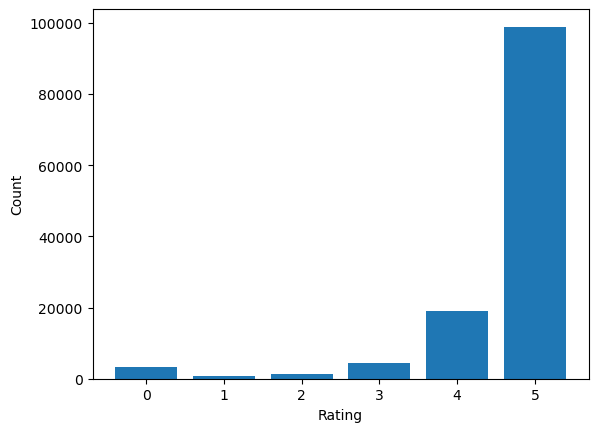

In [14]:
plt.bar(reduced_df.Rating.value_counts().index, reduced_df.Rating.value_counts().values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show();

### Train/Test Split

In [15]:
X = reduced_df.copy()
X_train, X_test = train_test_split(X, test_size = 0.25, random_state=123)

# Baseline Approaches

Selecting the error metric RMSE:

In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Simple Average of All Ratings

Calculating the simple mean of the dataset:

In [17]:
round(X_train['Rating'].mean(),3)

4.598

Calculating the training set error when applying the simple mean of the dataset as a prediction for each item:

In [18]:
pred = np.repeat(X_train['Rating'].mean(),len(X_train))
rmse(X_train['Rating'], pred)

0.9807334456363663

Applying the training set mean as test set predictions:

In [19]:
pred = np.repeat(X_train['Rating'].mean(),len(X_test))
rmse(X_test['Rating'], pred)

0.9767876929198569

## Naive User-Based Average

In [20]:
r_matrix = X_train.pivot_table(values='Rating', index='User', columns='Item')
mean_ratings_df = pd.DataFrame(r_matrix.mean(axis=1), columns=['mean_rating'])
mean_ratings_df.head()

,mean_rating
User,
0,5.000000
1,5.000000
2,5.000000
3,4.852459
4,4.441860


Apply as predictions to the training data:

In [21]:
user_based_avgs = X_train.merge(mean_ratings_df, how='left', on='User')
rmse(user_based_avgs['Rating'], user_based_avgs['mean_rating'])

0.793302888489952

Apply as predictions to the test data:

In [22]:
user_based_avgs = X_test.merge(mean_ratings_df, how='left', on='User')

Determine the number of test set rows containing a user not found in the test data:

In [23]:
user_based_avgs[user_based_avgs['mean_rating'].isnull()].count()[0]

2139

Setting the rating for such rows to the global mean:

In [24]:
null_test_users = user_based_avgs[user_based_avgs['mean_rating'].isnull()]
user_based_avgs = user_based_avgs.dropna(subset=['mean_rating'])
null_test_users['mean_rating'] = X_train['Rating'].mean()
X_test = pd.concat([user_based_avgs, null_test_users])

Calculating the test set error:

In [25]:
rmse(X_test['Rating'], X_test['mean_rating'])

1.0289210490921488

<i>As an exercise:</i> Instead of using the global average where test set users are not found in the training data, we could experiment with using the user-based (or item-based) average as a filler.

## Naive Item-Based Average

Applying to the training set:

In [26]:
r_matrix = X_train.pivot_table(values='Rating', index='Item', columns='User')
mean_ratings_df = pd.DataFrame(r_matrix.mean(axis=1), columns=['mean_rating'])
item_based_avgs = X_train.merge(mean_ratings_df, how='left', on='Item')
rmse(item_based_avgs['Rating'], item_based_avgs['mean_rating'])

0.9572402617949772

Applying to the test set:

In [27]:
X_test.drop(columns=['mean_rating'], inplace=True)
item_based_avgs = X_test.merge(mean_ratings_df, how='left', on='Item')

Counting test set items not present in training set:

In [28]:
item_based_avgs[item_based_avgs['mean_rating'].isnull()].count()[0]

0

Calculating the error:

In [29]:
rmse(item_based_avgs['Rating'], item_based_avgs['mean_rating'])

0.9790888774877435

## Average Weighted Rating by Vote Count

We'll look at fancier ways of weighting things, including for individual items and users, in subsequent notebooks. For now, we'll just take the global weighted average of ratings, weighted by vote count.

In [30]:
global_wmean = sum(X_train['Rating'] * X_train['vote_count']) / sum(X_train['vote_count'])

Then, take a look at its error magnitude as a global prediction upon the training set:

In [31]:
X_train['wmean_rating'] = np.repeat(global_wmean,len(X_train))
rmse(X_train['Rating'], X_train['wmean_rating'])

0.9809462319951424

Then, evaluate upon the test set:

In [32]:
X_test['wmean_rating'] = np.repeat(global_wmean,len(X_test))
rmse(X_test['Rating'], X_test['wmean_rating'])

0.977025610848176

## IMDB's Weighted Rating Formula

IMDB has been known to use a weighting formula of:
    
<h1>$Weighted Rating = \left( \frac{v}{v+m} \right) \times R + \left( \frac{m}{v+m} \right) \times C$</h1>

- $v$ is the number of votes garnered by the movie
- $m$ is the minimum number of votes required for the movie to be in the chart (the
prerequisite)
- $R$ is the mean rating of the movie
- $C$ is the mean rating of all the movies in the dataset

Source: Analytics Vidhya

Evaluating upon the training set:

In [76]:
X_train = X_train.reset_index().drop(columns='index')
X_train['wranking'] = np.NaN

for i in tqdm(range(len(X_train))):
    item = X_train['Item'][i]
    v = X_train['vote_count'][i]
    # taking the mean of the below because the dataframe returns a list of identical numbers
    R = item_based_avgs[item_based_avgs['Item'] == item]['mean_rating'].mean() 
    C = X_train['Rating'].mean().mean()
    m = 50 # this value is arbitrarily chosen
    wranking = ( v/(v+m) ) * R + ( m/(v+m) ) * C
    if pd.Series(wranking).isnull()[0] == True:
        wranking = X_train['Rating'].mean().mean()
    X_train['wranking'][i] = wranking

100%|██████████| 95805/95805 [09:00<00:00, 177.20it/s]


In [78]:
rmse(X_train['Rating'],X_train['wranking'])

0.9643367634179861

<i>As an exercise:</i> determine the IMBD-method's efficacy upon the test set.